In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm import tqdm
import re
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score 
import lightgbm as lgb
import pickle

In [58]:
lgb_clf = pickle
with open('../model/lgb_clf.pickle', 'rb') as f:
    lgb_clf = pickle.load(f)

In [59]:
importance = pd.DataFrame(lgb_clf.feature_importance(), index=lgb_clf.feature_name(), columns=['importance'])

In [60]:
imp_sort = importance.sort_values('importance', ascending=False)

In [61]:
imp_sort

,importance
全国勝率,14967
スタートタイミング,14728
展示,14704
モーター2連率,13077
ボート2連率,12099
全国2連率,10829
選手登番,10448
当地勝率,10415
当地2連率,9467
艇番,9270


In [62]:
x = [i for i in range(1, imp_sort.shape[0]+1)]


In [63]:
x

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

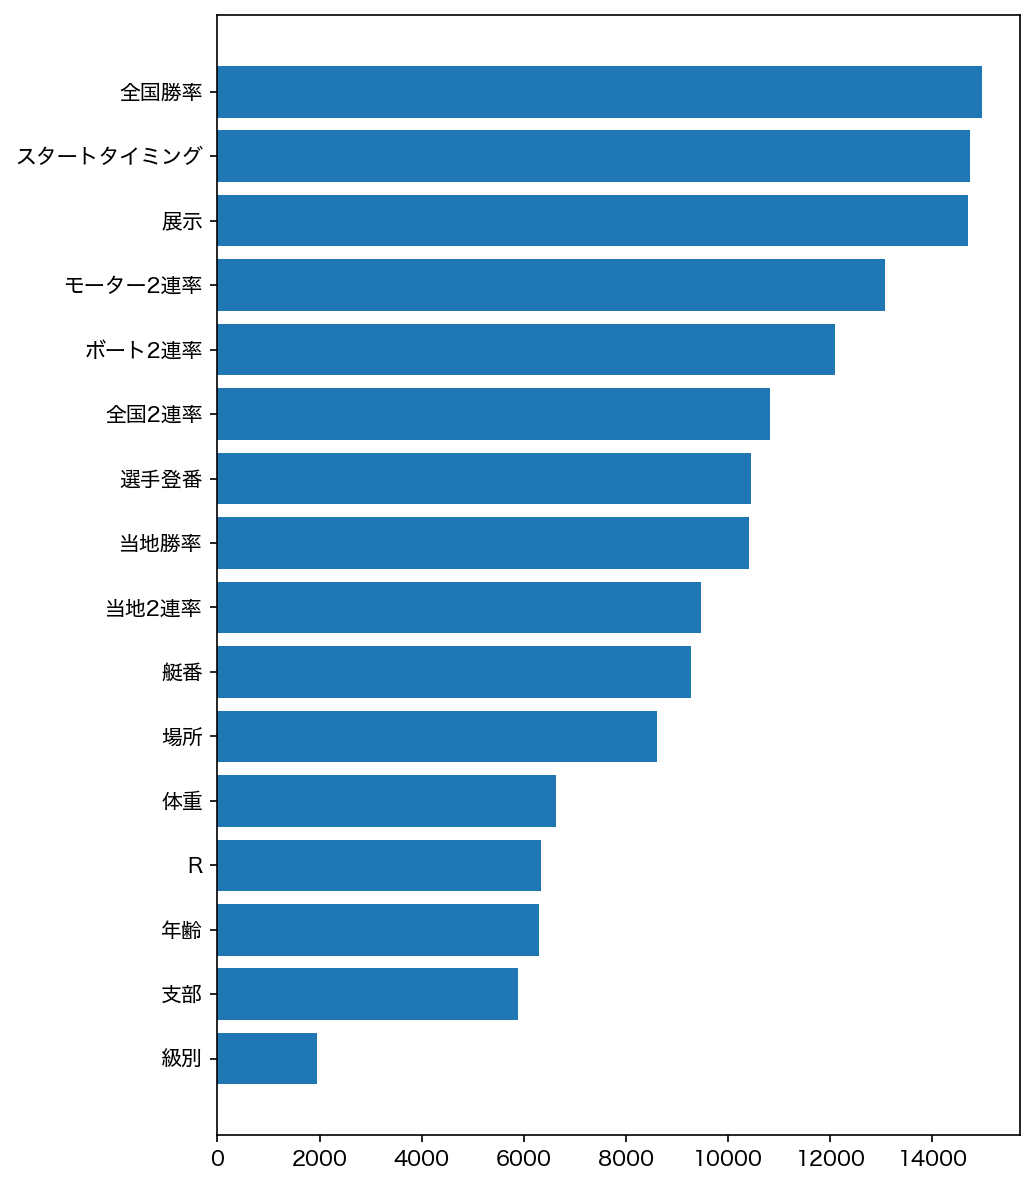

In [64]:
plt.rcParams['font.family'] = "Hiragino sans"
plt.figure(dpi=150,figsize=(7,8))
label_x = imp_sort.index
x = [-i for i in range(1,imp_sort.shape[0]+1)]
y = imp_sort.loc[:,"importance"]

plt.barh(x,y, align='center')
plt.yticks(x, label_x)
plt.tight_layout()
plt.savefig("../model/importance.png")
plt.show()
